In [1]:
pip install pandas numpy lightgbm holidays scikit-learn scipy statsmodels seaborn matplotlib ruptures xgboost

  Using cached holidays-0.91-py3-none-any.whl.metadata (50 kB)
Using cached holidays-0.91-py3-none-any.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\LP204\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


Starting Lumina Stage-1 Pipeline...

Parsing DateTime columns...
Merging datasets...
Engineering features...
Final dataset shape: (282527, 14)

Training LightGBM Quantile Model...

===== FINANCIAL RESULTS =====
Total Deviation Penalty: ₹11,221,903.11
Forecast Bias: +8.27%
95th Percentile Abs Deviation: 261.21


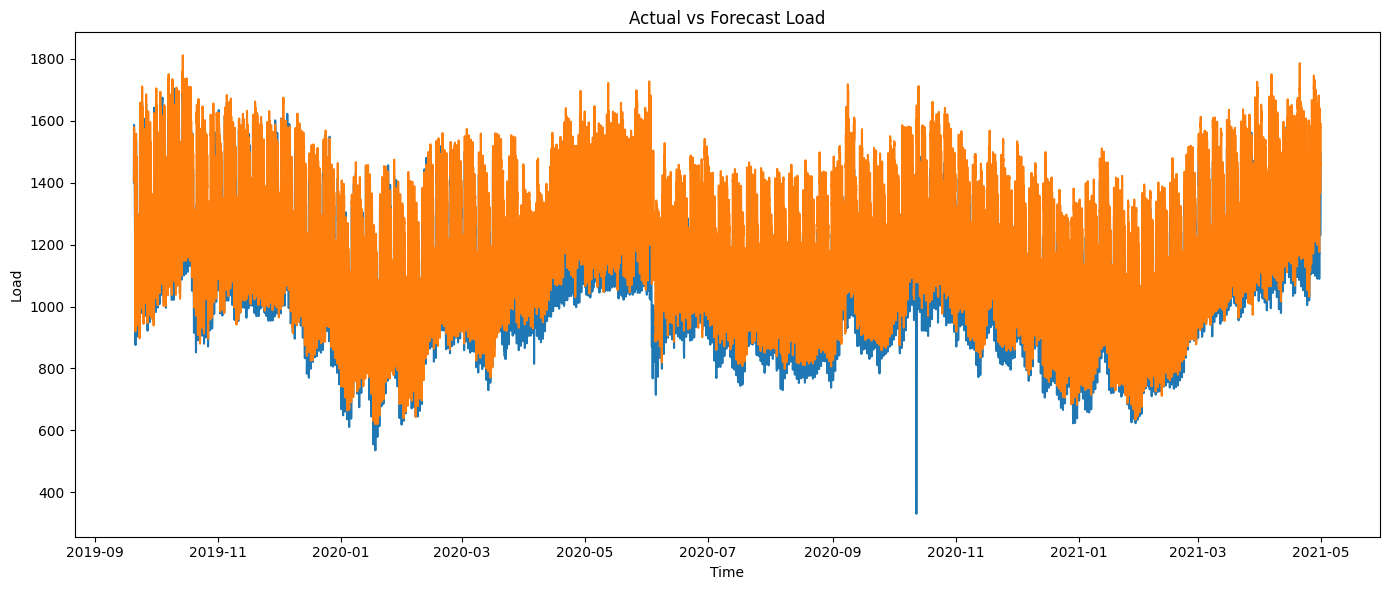

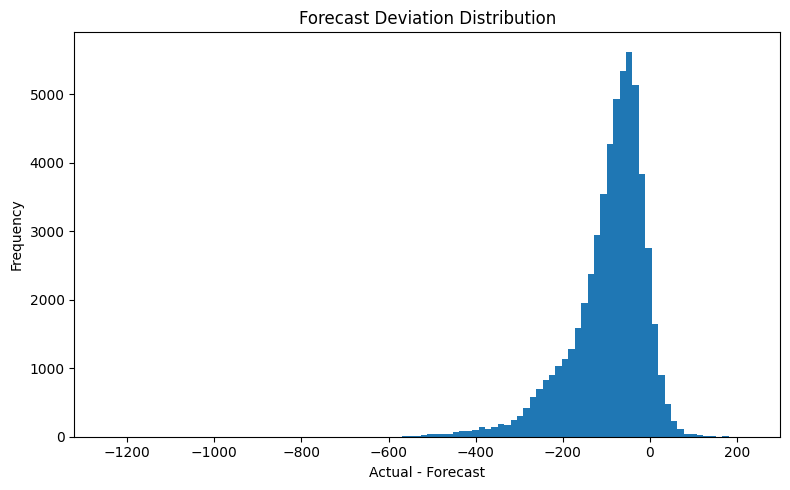

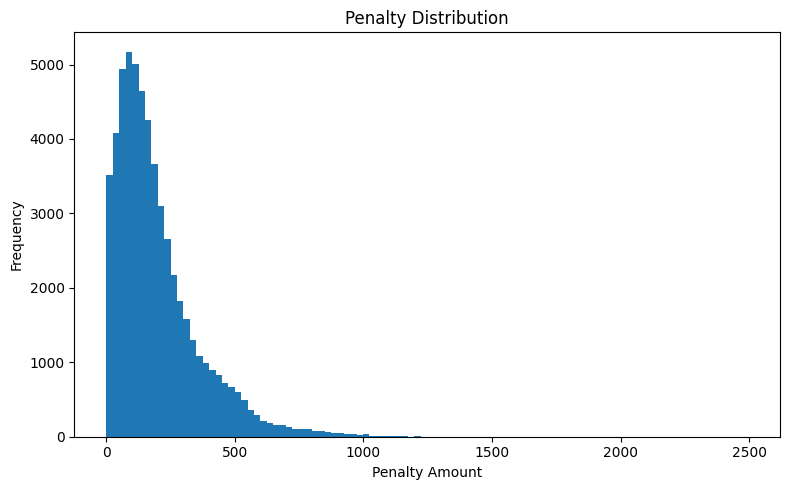

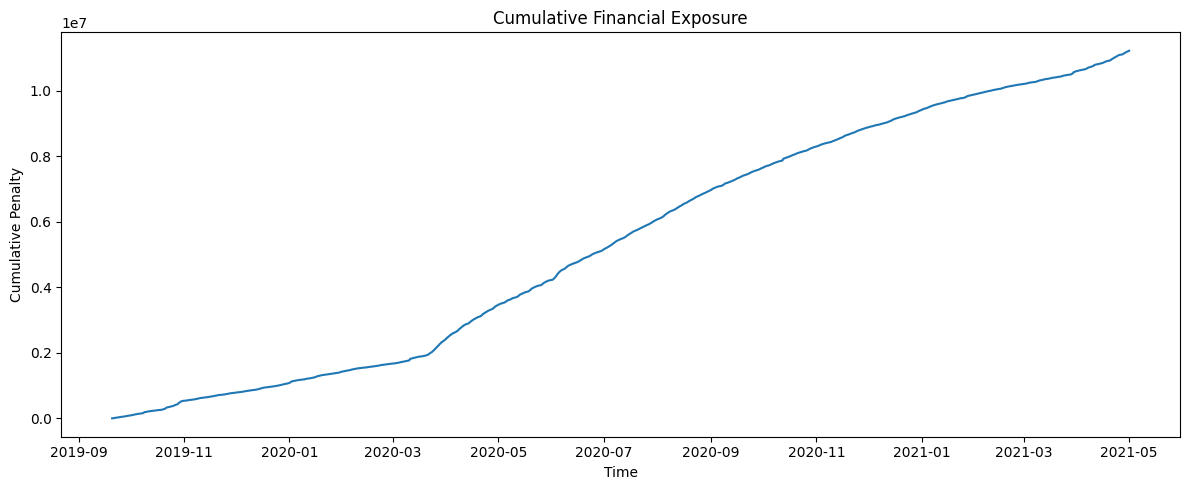

Visualization completed.

Pipeline completed successfully.
Results saved at: C:\Users\LP204\Downloads\stage1_risk_results.csv


In [5]:
"""
Lumina Energy - Forecast Risk Advisory: Stage 1 Pipeline
FULL FINAL COMPLETE VERSION (With Visualizations)
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
import holidays
import warnings
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")

# ==========================================
# FILE PATHS
# ==========================================

BASE_PATH = Path.home() / "Downloads"

LOAD_DATA_PATH = BASE_PATH / "Electric_Load_Data_Train.csv"
WEATHER_DATA_PATH = BASE_PATH / "External_Factor_Data_Train.csv"

# ==========================================
# DATA PROCESSOR
# ==========================================

class LuminaDataProcessor:
    def __init__(self, forecast_horizon_hrs=48, interval_mins=15):
        self.intervals_per_hour = 60 // interval_mins
        self.horizon_steps = forecast_horizon_hrs * self.intervals_per_hour
        self.mh_holidays = holidays.India(subdiv='MH', years=range(2013, 2025))

    def process(self, load_df, weather_df):

        print("\nParsing DateTime columns...")

        load_df['DateTime'] = pd.to_datetime(
            load_df['DATETIME'],
            format='%d%b%Y:%H:%M:%S',
            errors='coerce'
        )

        weather_df['DateTime'] = pd.to_datetime(
            weather_df['DATETIME'],
            format='%d%b%Y:%H:%M:%S',
            errors='coerce'
        )

        load_df.rename(columns={'LOAD': 'Load'}, inplace=True)
        weather_df.rename(columns={
            'ACT_TEMP': 'Temperature',
            'ACT_HUMIDITY': 'Humidity'
        }, inplace=True)

        load_df.dropna(subset=['DateTime'], inplace=True)
        weather_df.dropna(subset=['DateTime'], inplace=True)

        print("Merging datasets...")
        df = pd.merge(
            load_df[['DateTime', 'Load']],
            weather_df[['DateTime', 'Temperature', 'Humidity', 'ACT_RAIN', 'COOL_FACTOR']],
            on='DateTime',
            how='inner'
        )

        df.set_index('DateTime', inplace=True)
        df.sort_index(inplace=True)

        print("Engineering features...")

        # Time Features
        df['Hour'] = df.index.hour
        df['DayOfWeek'] = df.index.dayofweek
        df['Month'] = df.index.month
        df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)
        df['Is_Peak'] = ((df['Hour'] >= 18) & (df['Hour'] <= 22)).astype(int)
        df['Is_Holiday'] = df.index.normalize().isin(self.mh_holidays).astype(int)

        # Weather Impact
        df['Heat_Impact'] = df['Temperature'] * (1 + df['Humidity'] / 100)

        # Lag Features (NO LEAKAGE)
        df['Load_Lag_48h'] = df['Load'].shift(self.horizon_steps)
        df['Load_Lag_1Week'] = df['Load'].shift(
            self.horizon_steps + 7 * 24 * self.intervals_per_hour
        )

        df.dropna(inplace=True)

        print("Final dataset shape:", df.shape)
        return df


# ==========================================
# FORECAST MODEL
# ==========================================

class RiskOptimizedForecaster:
    def __init__(self, quantile=0.667):

        self.model = lgb.LGBMRegressor(
            objective='quantile',
            alpha=quantile,
            n_estimators=400,
            learning_rate=0.05,
            max_depth=8,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=-1
        )

    def train(self, X, y):
        print("\nTraining LightGBM Quantile Model...")
        self.model.fit(X, y)

    def predict(self, X):
        return self.model.predict(X)


# ==========================================
# FINANCIAL SIMULATOR
# ==========================================

class FinancialExposureSimulator:
    def __init__(self, under_penalty=4, over_penalty=2):
        self.under_penalty = under_penalty
        self.over_penalty = over_penalty

    def evaluate(self, actual, forecast):

        deviation = actual - forecast

        penalty = np.where(
            deviation > 0,
            deviation * self.under_penalty,
            abs(deviation) * self.over_penalty
        )

        total_penalty = penalty.sum()
        bias = (forecast.sum() - actual.sum()) / actual.sum() * 100
        p95 = np.percentile(np.abs(deviation), 95)

        print("\n===== FINANCIAL RESULTS =====")
        print(f"Total Deviation Penalty: ₹{total_penalty:,.2f}")
        print(f"Forecast Bias: {bias:+.2f}%")
        print(f"95th Percentile Abs Deviation: {p95:.2f}")
        print("=============================")

        return pd.DataFrame({
            "Actual": actual,
            "Forecast": forecast,
            "Deviation": deviation,
            "Penalty": penalty
        })


# ==========================================
# VISUALIZATION
# ==========================================

def visualize_results(results_df):

    # 1️⃣ Actual vs Forecast
    plt.figure(figsize=(14,6))
    plt.plot(results_df.index, results_df["Actual"])
    plt.plot(results_df.index, results_df["Forecast"])
    plt.title("Actual vs Forecast Load")
    plt.xlabel("Time")
    plt.ylabel("Load")
    plt.tight_layout()
    plt.show()

    # 2️⃣ Deviation Distribution
    plt.figure(figsize=(8,5))
    plt.hist(results_df["Deviation"], bins=100)
    plt.title("Forecast Deviation Distribution")
    plt.xlabel("Actual - Forecast")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # 3️⃣ Penalty Distribution
    plt.figure(figsize=(8,5))
    plt.hist(results_df["Penalty"], bins=100)
    plt.title("Penalty Distribution")
    plt.xlabel("Penalty Amount")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    # 4️⃣ Cumulative Penalty
    plt.figure(figsize=(12,5))
    cumulative_penalty = results_df["Penalty"].cumsum()
    plt.plot(results_df.index, cumulative_penalty)
    plt.title("Cumulative Financial Exposure")
    plt.xlabel("Time")
    plt.ylabel("Cumulative Penalty")
    plt.tight_layout()
    plt.show()

    print("Visualization completed.")


# ==========================================
# MAIN EXECUTION
# ==========================================

if __name__ == "__main__":

    try:

        print("Starting Lumina Stage-1 Pipeline...")

        load_raw = pd.read_csv(LOAD_DATA_PATH)
        weather_raw = pd.read_csv(WEATHER_DATA_PATH)

        processor = LuminaDataProcessor()
        df = processor.process(load_raw, weather_raw)

        # Train-Test Split (Time Series Safe)
        train_size = int(len(df) * 0.8)
        train_df = df.iloc[:train_size]
        test_df = df.iloc[train_size:]

        X_train = train_df.drop(columns=['Load'])
        y_train = train_df['Load']
        X_test = test_df.drop(columns=['Load'])
        y_test = test_df['Load']

        # Train Model
        model = RiskOptimizedForecaster()
        model.train(X_train, y_train)

        predictions = model.predict(X_test)

        # Financial Evaluation
        simulator = FinancialExposureSimulator()
        results = simulator.evaluate(y_test, predictions)

        # Restore time index
        results.index = y_test.index

        # Visualize
        visualize_results(results)

        # Save Output
        output_path = BASE_PATH / "stage1_risk_results.csv"
        results.to_csv(output_path)

        print("\nPipeline completed successfully.")
        print("Results saved at:", output_path)

    except Exception as e:
        print("\nERROR:", e)